Protons: 1047, Kaons: 8227
Calorimetry (z0, z1)            AUC=0.659  Acc=0.581
Topology (z1, z3)               AUC=0.711  Acc=0.622
All (z0–z3)                     AUC=0.718  Acc=0.625

Event-level agreement (N=9274):
  Both correct:       4543  (49.0%)
  Calo only correct:   843  (9.1%)
  Topo only correct:  1222  (13.2%)
  Both wrong:         2666  (28.7%)


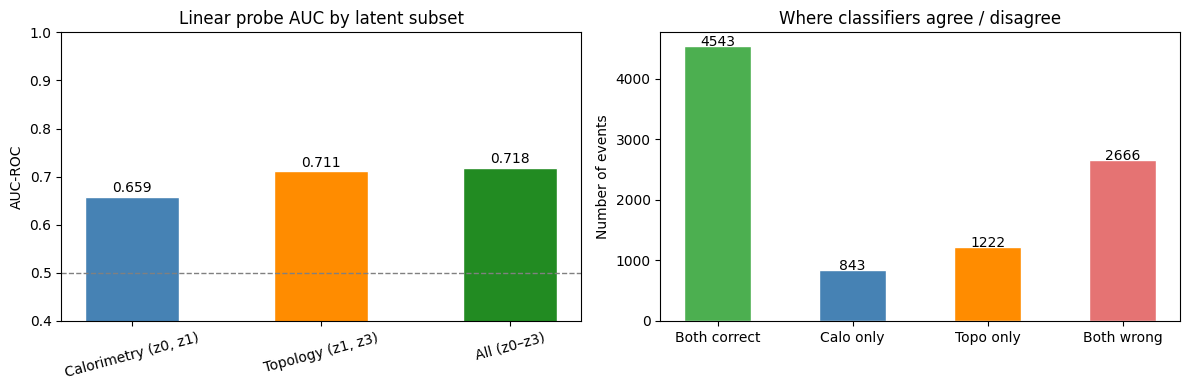

In [4]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.pipeline import Pipeline

# ── load latents ──────────────────────────────────────────────────────────────
with open("../../configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

name = (
    f"model_{cfg['model']['type']}"
    f"_latent{cfg['model']['latent']}"
    f"_ch{'_'.join(str(c) for c in cfg['model']['channels'])}"
    f"_beta{cfg['train']['beta']}"
    f"_lr{cfg['optimizer']['lr']}"
    f"_epoch{cfg['train']['epochs']}"
    f"_act{cfg['model']['activation']}"
    f"_kern{cfg['model']['kernel']}"
    f"_stride{cfg['model']['stride']}"
    f"_pad{cfg['model']['padding']}"
)

inference_dir = Path(cfg["output"]["inference_dir"]) / name

train = np.load(inference_dir / "train.npz")
val   = np.load(inference_dir / "val.npz")
kaon  = np.load(inference_dir / "kaon.npz")

# use val protons (held out from VAE training) + kaon candidates
# avoids any risk of the classifier benefiting from VAE training memorisation
proton_latents = val["latents"]    # (N_p, 4)
kaon_latents   = kaon["latents"]   # (N_k, 4)

X = np.concatenate([proton_latents, kaon_latents], axis=0)   # (N, 4)
y = np.concatenate([
    np.zeros(len(proton_latents)),   # 0 = proton
    np.ones(len(kaon_latents)),      # 1 = kaon
])

print(f"Protons: {len(proton_latents)}, Kaons: {len(kaon_latents)}")

# ── define subsets ────────────────────────────────────────────────────────────
subsets = {
    "Calorimetry (z0, z1)": [0, 1],
    "Topology (z1, z3)":    [1, 3],
    "All (z0–z3)":          [0, 1, 2, 3],
}

# ── cross-validated evaluation ────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

results    = {}
pred_proba = {}   # store per-sample predicted probabilities for comparison

for label, dims in subsets.items():
    X_sub = X[:, dims]

    # predicted probability of being kaon, assembled from held-out folds
    proba = cross_val_predict(
        clf_pipeline, X_sub, y,
        cv=cv, method="predict_proba"
    )[:, 1]

    auc  = roc_auc_score(y, proba)
    pred = (proba > 0.5).astype(int)
    acc  = accuracy_score(y, pred)

    results[label]    = {"AUC": auc, "Accuracy": acc}
    pred_proba[label] = proba

    print(f"{label:30s}  AUC={auc:.3f}  Acc={acc:.3f}")

# ── event-level agreement between the two partial classifiers ─────────────────
calo_pred = (pred_proba["Calorimetry (z0, z1)"] > 0.5).astype(int)
topo_pred = (pred_proba["Topology (z1, z3)"]    > 0.5).astype(int)

agree_correct   = ((calo_pred == y) & (topo_pred == y)).sum()
calo_only       = ((calo_pred == y) & (topo_pred != y)).sum()
topo_only       = ((calo_pred != y) & (topo_pred == y)).sum()
both_wrong      = ((calo_pred != y) & (topo_pred != y)).sum()
N               = len(y)

print(f"\nEvent-level agreement (N={N}):")
print(f"  Both correct:       {agree_correct:4d}  ({100*agree_correct/N:.1f}%)")
print(f"  Calo only correct:  {calo_only:4d}  ({100*calo_only/N:.1f}%)")
print(f"  Topo only correct:  {topo_only:4d}  ({100*topo_only/N:.1f}%)")
print(f"  Both wrong:         {both_wrong:4d}  ({100*both_wrong/N:.1f}%)")

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: AUC bar chart
labels = list(results.keys())
aucs   = [results[l]["AUC"] for l in labels]
colours = ["steelblue", "darkorange", "forestgreen"]
axes[0].bar(labels, aucs, color=colours, edgecolor="white", width=0.5)
axes[0].axhline(0.5, color="grey", linestyle="--", linewidth=1, label="Chance")
axes[0].set_ylim(0.4, 1.0)
axes[0].set_ylabel("AUC-ROC")
axes[0].set_title("Linear probe AUC by latent subset")
axes[0].tick_params(axis="x", rotation=15)
for i, auc in enumerate(aucs):
    axes[0].text(i, auc + 0.01, f"{auc:.3f}", ha="center", fontsize=10)

# right: event-level breakdown stacked bar
categories  = ["Both correct", "Calo only", "Topo only", "Both wrong"]
counts      = [agree_correct, calo_only, topo_only, both_wrong]
bar_colours = ["#4CAF50", "steelblue", "darkorange", "#e57373"]
axes[1].bar(categories, counts, color=bar_colours, edgecolor="white", width=0.5)
axes[1].set_ylabel("Number of events")
axes[1].set_title("Where classifiers agree / disagree")
for i, c in enumerate(counts):
    axes[1].text(i, c + 0.5, str(c), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../../figs/latents-features/linear_probe.png", dpi=150, bbox_inches="tight")
plt.show()